In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:\\Users\\Lenovo\\Downloads\\apple_global_sales_dataset (1).csv')
df.head

<bound method NDFrame.head of              sale_id   sale_date  year quarter     month    country  \
0      APPL-00000001  2022-01-03  2022      Q1   January  Argentina   
1      APPL-00000002  2022-01-04  2022      Q1   January  Argentina   
2      APPL-00000003  2022-05-18  2022      Q2       May  Argentina   
3      APPL-00000004  2022-05-23  2022      Q2       May  Argentina   
4      APPL-00000005  2022-07-13  2022      Q3      July  Argentina   
...              ...         ...   ...     ...       ...        ...   
11495  APPL-00011496  2024-02-08  2024      Q1  February    Vietnam   
11496  APPL-00011497  2024-02-15  2024      Q1  February    Vietnam   
11497  APPL-00011498  2024-08-28  2024      Q3    August    Vietnam   
11498  APPL-00011499  2024-08-31  2024      Q3    August    Vietnam   
11499  APPL-00011500  2024-10-10  2024      Q4   October    Vietnam   

              region          city              product_name     category  \
0      South America  Buenos Aires      

In [4]:
df.isnull().mean()*100

sale_id                    0.000000
sale_date                  0.000000
year                       0.000000
quarter                    0.000000
month                      0.000000
country                    0.000000
region                     0.000000
city                       0.000000
product_name               0.000000
category                   0.000000
storage                   41.773913
color                      0.000000
unit_price_usd             0.000000
discount_pct               0.000000
units_sold                 0.000000
discounted_price_usd       0.000000
revenue_usd                0.000000
currency                   0.000000
fx_rate_to_usd             0.000000
revenue_local_currency     0.000000
sales_channel              0.000000
payment_method             0.000000
customer_segment           0.000000
customer_age_group         0.000000
previous_device_os        70.052174
customer_rating           29.217391
return_status              0.000000
dtype: float64

In [5]:
df['customer_rating'] = df['customer_rating'].fillna(
    df.groupby('product_name')['customer_rating'].transform('mean'))
df.isnull().mean()*100

sale_id                    0.000000
sale_date                  0.000000
year                       0.000000
quarter                    0.000000
month                      0.000000
country                    0.000000
region                     0.000000
city                       0.000000
product_name               0.000000
category                   0.000000
storage                   41.773913
color                      0.000000
unit_price_usd             0.000000
discount_pct               0.000000
units_sold                 0.000000
discounted_price_usd       0.000000
revenue_usd                0.000000
currency                   0.000000
fx_rate_to_usd             0.000000
revenue_local_currency     0.000000
sales_channel              0.000000
payment_method             0.000000
customer_segment           0.000000
customer_age_group         0.000000
previous_device_os        70.052174
customer_rating            0.000000
return_status              0.000000
dtype: float64

In [6]:
df.drop('storage', axis=1)

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,1.343448e+05,Third-Party Retailer,Cash,Government,45–54,NaN,4.100000,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,1.155971e+05,Authorized Reseller,Debit Card,Business,45–54,NaN,4.800000,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1.066342e+06,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.300000,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3.506045e+06,Carrier Store,Credit Card,Education,45–54,NaN,4.046073,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1.952780e+06,Apple Store,Net Banking,Education,18–24,NaN,3.991954,Kept
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,APPL-00011496,2024-02-08,2024,Q1,February,Vietnam,Asia,Nha Trang,Apple Watch Series 9,Apple Watch,...,VND,24500.0,1.957550e+07,Third-Party Retailer,Gift Card,Individual,18–24,NaN,4.000000,Kept
11496,APPL-00011497,2024-02-15,2024,Q1,February,Vietnam,Asia,Nha Trang,Mac Pro (M2 Ultra),Mac,...,VND,24500.0,1.663898e+08,Corporate / B2B,Gift Card,Education,45–54,NaN,4.900000,Kept
11497,APPL-00011498,2024-08-28,2024,Q3,August,Vietnam,Asia,Nha Trang,iPhone 15,iPhone,...,VND,24500.0,8.657932e+07,Authorized Reseller,Debit Card,Government,35–44,iOS 16,3.800000,Kept
11498,APPL-00011499,2024-08-31,2024,Q3,August,Vietnam,Asia,Nha Trang,iPhone SE (3rd Gen),iPhone,...,VND,24500.0,1.075526e+07,Apple Store,EMI / Installment,Education,55+,iOS 17,3.992655,Kept


In [8]:
total_sales_each_product = df.groupby('product_name', as_index=False)['revenue_usd'].sum().sort_values(by='revenue_usd',ascending=False)
print(total_sales_each_product)

                    product_name  revenue_usd
13            Mac Pro (M2 Ultra)   3724222.55
18  MacBook Pro 16-inch (M3 Pro)   1491289.26
17      MacBook Pro 14-inch (M3)   1027383.82
15      MacBook Air 13-inch (M2)    634573.15
24             iMac 24-inch (M3)    624597.43
33             iPhone 13 Pro Max    605116.33
41             iPhone 15 Pro Max    597448.92
16      MacBook Air 15-inch (M2)    556390.06
29       iPad Pro 12.9-inch (M2)    538088.68
36                 iPhone 14 Pro    525599.32
40                 iPhone 15 Pro    509914.40
32                 iPhone 13 Pro    476574.66
39                iPhone 15 Plus    448101.82
35                iPhone 14 Plus    440069.66
34                     iPhone 14    438088.35
37             iPhone 14 Pro Max    436050.41
10           Apple Watch Ultra 2    434910.30
28         iPad Pro 11-inch (M2)    416016.23
30                     iPhone 13    361787.15
38                     iPhone 15    353607.33
31                iPhone 13 Mini  

KPIs

In [9]:
total_sales = df['revenue_usd'].sum()
print("Total sales:",total_sales)

Total sales: 18035669.25


In [10]:
items_sold = df['units_sold'].sum()
print("Item sold:",items_sold)

Item sold: 23270


In [11]:
avg_items_sold = df['units_sold'].mean()
print("Average item sold per order:",avg_items_sold)

Average item sold per order: 2.0234782608695654


In [12]:
avg_rating = df['customer_rating'].mean()
print("Average Rating:",avg_rating)

Average Rating: 4.000919519227813


In [13]:
avg_discount = df['discount_pct'].mean()
print("Average Discount offered:",avg_discount)

Average Discount offered: 3.841565217391304


Product Vs sales

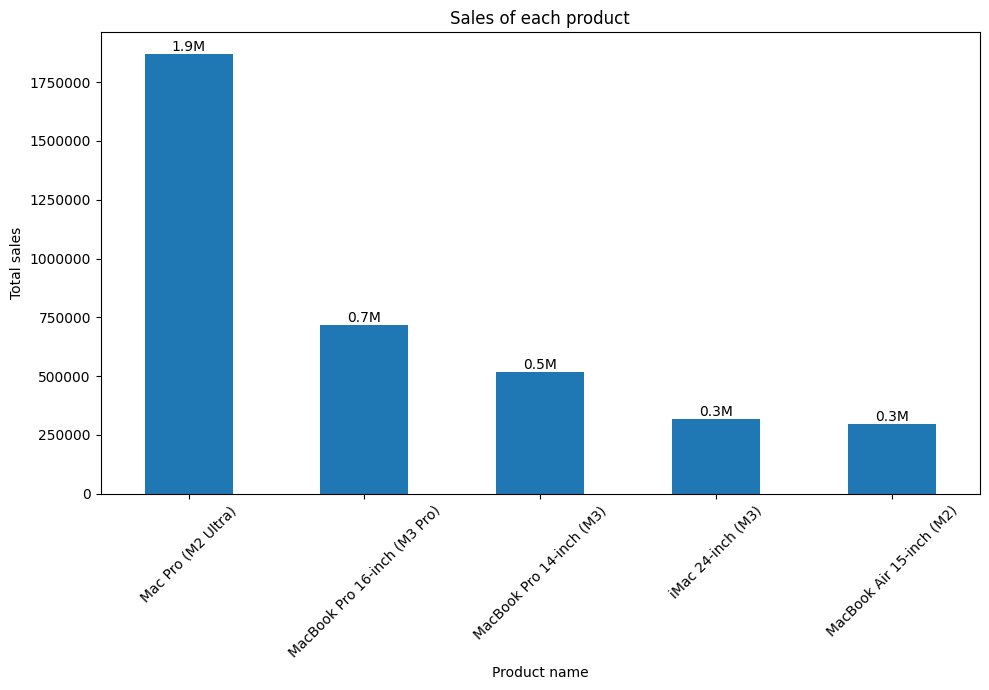

In [14]:
total_sales_each_product = df.groupby('product_name')['discounted_price_usd'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,7))
ax = total_sales_each_product.plot(kind='bar')

for i, v in enumerate(total_sales_each_product.values):
    ax.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Product name')
plt.ylabel('Total sales')
plt.title('Sales of each product')

plt.tight_layout()
plt.show()

Country vs Sales

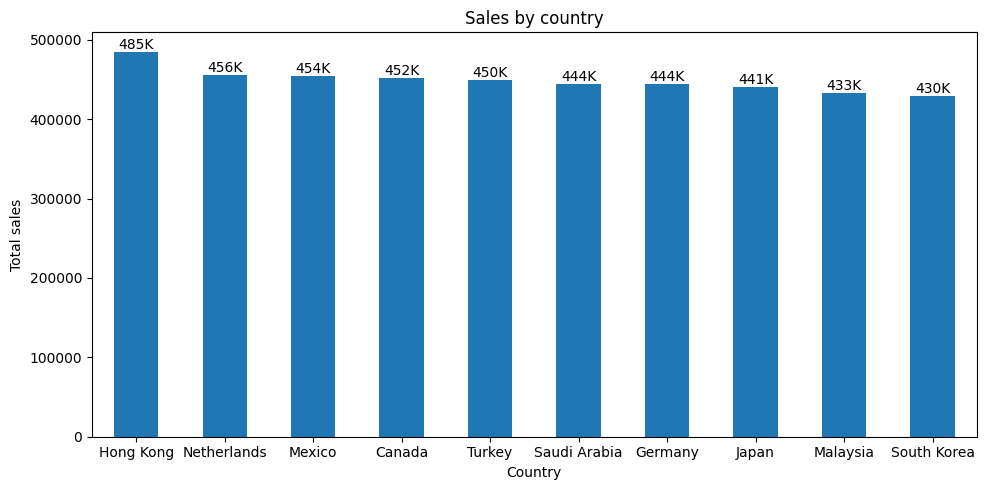

In [15]:
sales_by_country = df.groupby('country')['revenue_usd'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))

ax1 = sales_by_country.plot(kind='bar')

for i, v in enumerate(sales_by_country.values):
    ax1.text(i, v, f'{v/1e3:.0f}K', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.xlabel('Country')
plt.ylabel('Total sales')
plt.title('Sales by country')

plt.tight_layout()
plt.show()

Region vs Sales

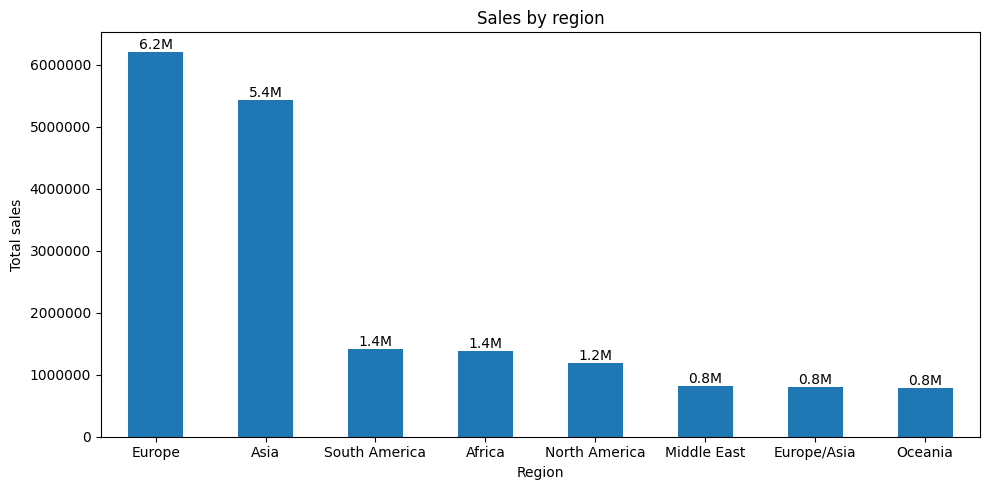

In [16]:
sales_by_country = df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))

ax2 = sales_by_country.plot(kind='bar')

for i, v in enumerate(sales_by_country.values):
    ax2.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Region')
plt.ylabel('Total sales')
plt.title('Sales by region')

plt.tight_layout()
plt.show()

Month vs Sales

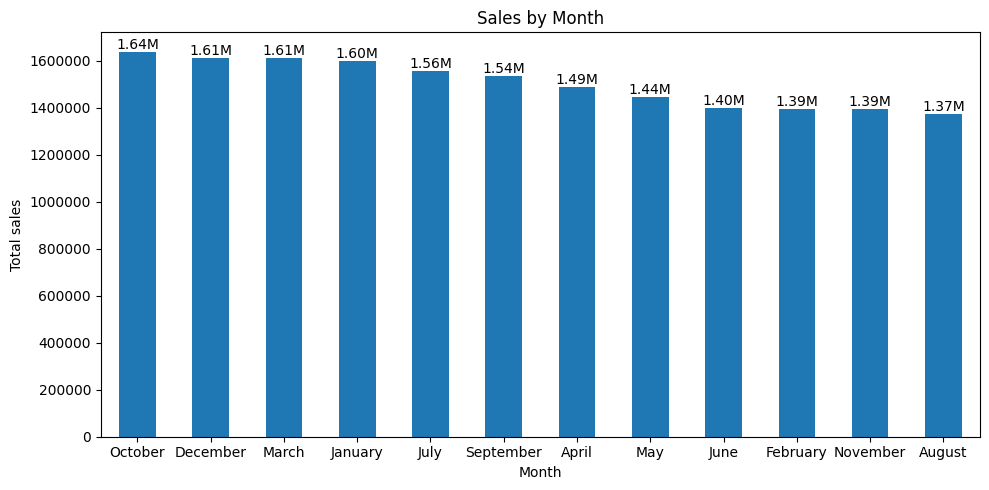

In [17]:
sales_by_month = df.groupby('month')['revenue_usd'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))

ax3 = sales_by_month.plot(kind='bar')

for i, v in enumerate(sales_by_month.values):
    ax3.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Month')
plt.ylabel('Total sales')
plt.title('Sales by Month')

plt.tight_layout()
plt.show()

Year vs Sales

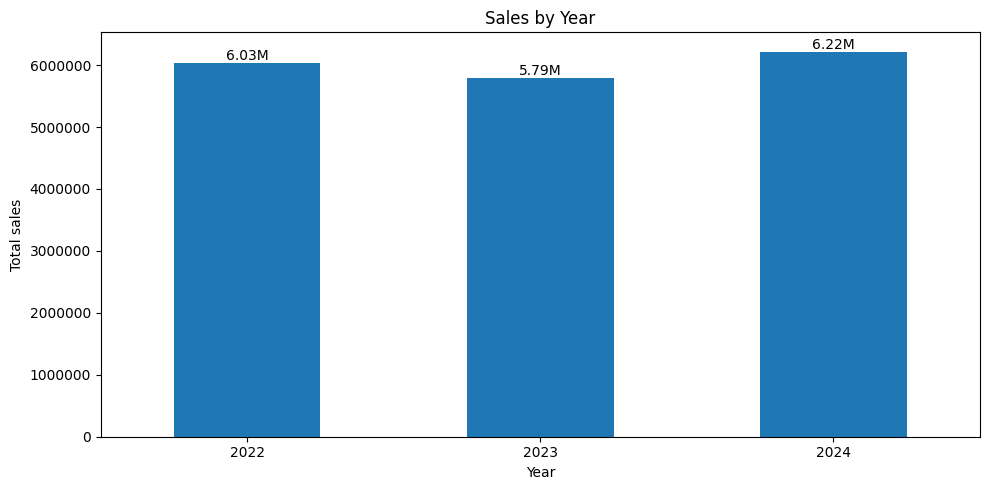

In [18]:
sales_by_year = df.groupby('year')['revenue_usd'].sum()
plt.figure(figsize=(10,5))

ax4 = sales_by_year.plot(kind='bar')

for i, v in enumerate(sales_by_year.values):
    ax4.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.title('Sales by Year')

plt.tight_layout()
plt.show()

Year vs Unit Sold

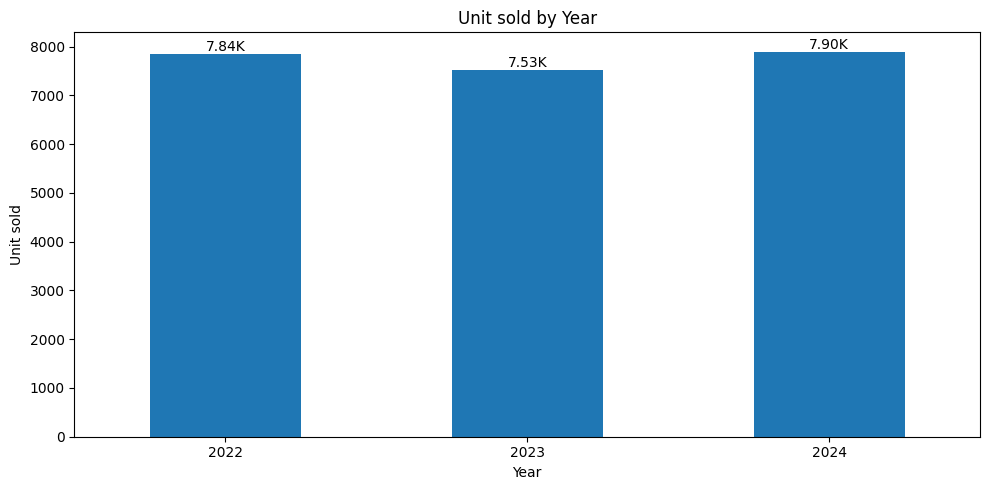

In [19]:
unit_sold_by_year = df.groupby('year')['units_sold'].sum()
plt.figure(figsize=(10,5))

ax9 = unit_sold_by_year.plot(kind='bar')

for i, v in enumerate(unit_sold_by_year.values):
    ax9.text(i, v, f'{v/1e3:.2f}K', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Year')
plt.ylabel('Unit sold')
plt.title('Unit sold by Year')

plt.tight_layout()
plt.show()

Channel vs Sales

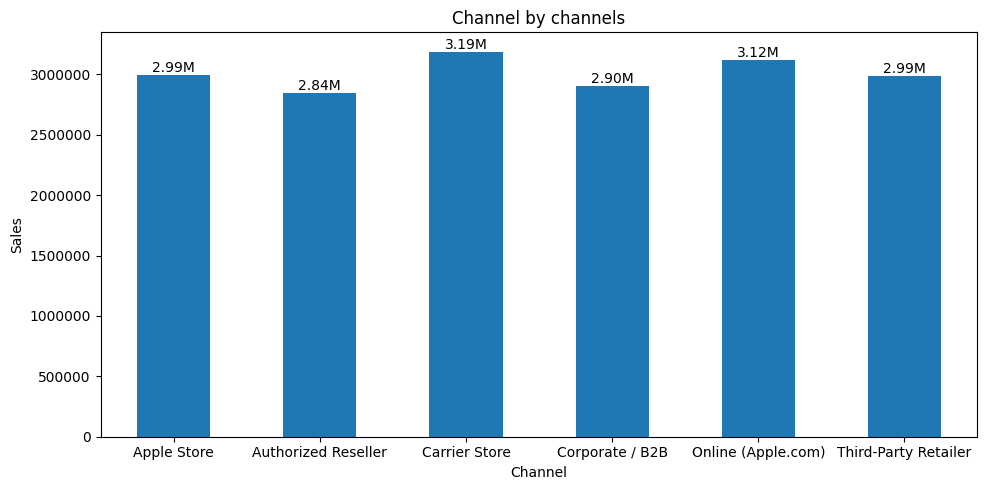

In [20]:
sales_by_channel = df.groupby('sales_channel')['revenue_usd'].sum()
plt.figure(figsize=(10,5))

ax10 = sales_by_channel.plot(kind='bar')

for i, v in enumerate(sales_by_channel.values):
    ax10.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Channel')
plt.ylabel('Sales')
plt.title('Channel by channels')

plt.tight_layout()
plt.show()

Age group vs Sales

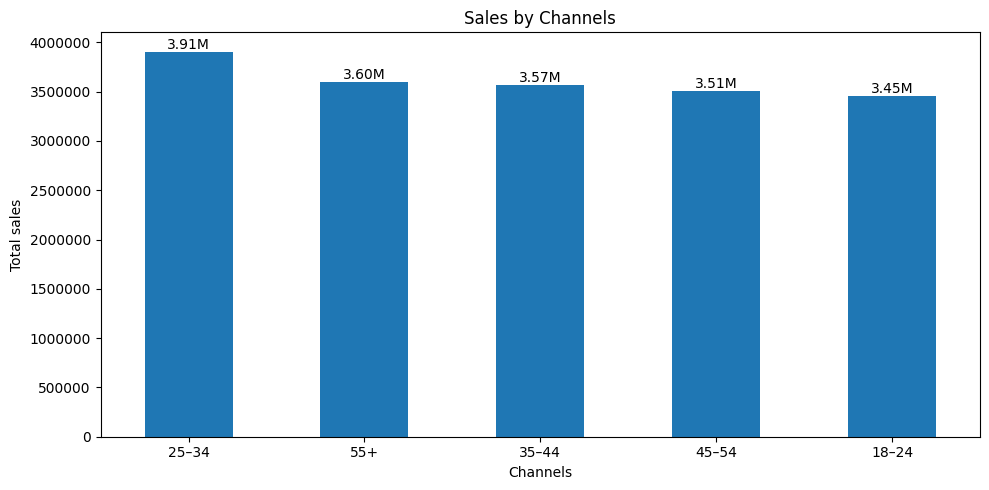

In [21]:
sales_by_age_group = df.groupby('customer_age_group')['revenue_usd'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))

ax6 = sales_by_age_group.plot(kind='bar')

for i, v in enumerate(sales_by_age_group.values):
    ax6.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Channels')
plt.ylabel('Total sales')
plt.title('Sales by Channels')

plt.tight_layout()
plt.show()

Color vs Sales

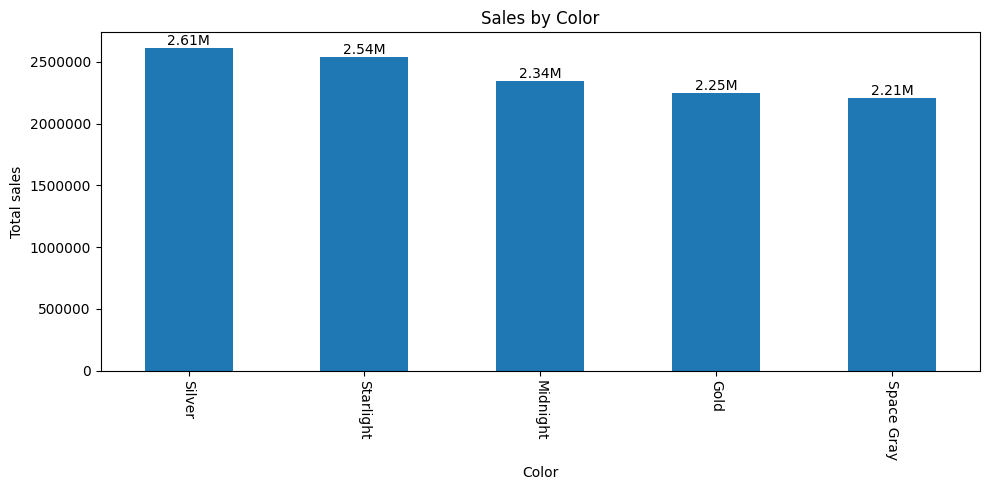

In [22]:
sales_by_color = df.groupby('color')['revenue_usd'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))

ax7 = sales_by_color.plot(kind='bar')

for i, v in enumerate(sales_by_color.values):
    ax7.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')

plt.xticks(rotation=-90)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Color')
plt.ylabel('Total sales')
plt.title('Sales by Color')

plt.tight_layout()
plt.show()

Reegion vs Unit sold

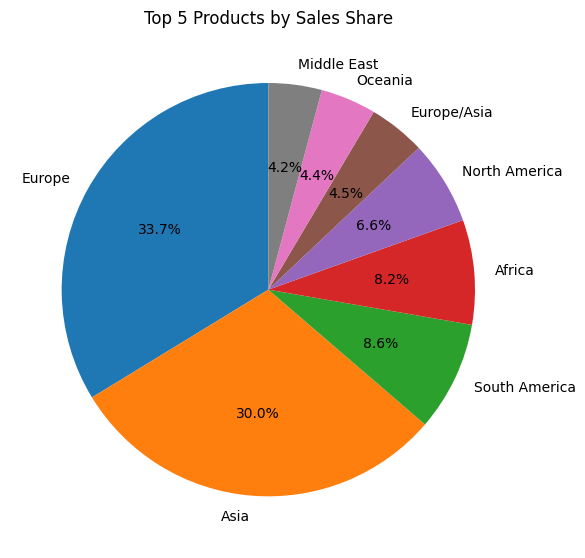

In [23]:
unit_sold_by_region = df.groupby('region')['units_sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(6,6))

plt.pie(
    unit_sold_by_region.values,
    labels=unit_sold_by_region.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Top 5 Products by Sales Share')

plt.tight_layout()
plt.show()

Discount vs Unit sold

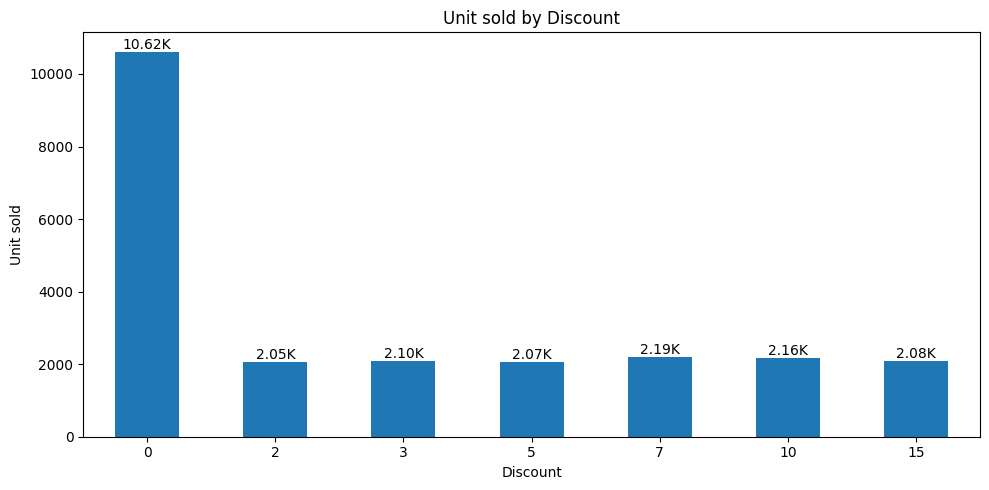

In [24]:
unit_sold_by_discount = df.groupby('discount_pct')['units_sold'].sum()
plt.figure(figsize=(10,5))

ax8 = unit_sold_by_discount.plot(kind='bar')

for i, v in enumerate(unit_sold_by_discount.values):
    ax8.text(i, v, f'{v/1e3:.2f}K', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Discount')
plt.ylabel('Unit sold')
plt.title('Unit sold by Discount')

plt.tight_layout()
plt.show()